<a href="https://colab.research.google.com/github/mission365/Deep-Learning/blob/main/perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Iris dataset
iris = load_iris()

# Take only two classes: setosa (0) and versicolor (1)
# Original labels: 0=setosa, 1=versicolor, 2=virginica
X = iris.data[:100, [0, 2]]  # features: sepal length, petal length
y = iris.target[:100]        # labels: 0 or 1

# Convert labels to binary: 0 (versicolor) and 1 (setosa) — but let's keep as is
# Actually, setosa=0, versicolor=1. Let's make setosa=1, versicolor=0 for clarity
y = 1 - y  # Now: setosa=1, versicolor=0

print(f"Feature shape: {X.shape}")
print(f"Labels: unique {np.unique(y)} (1=setosa, 0=versicolor)")

Feature shape: (100, 2)
Labels: unique [0 1] (1=setosa, 0=versicolor)


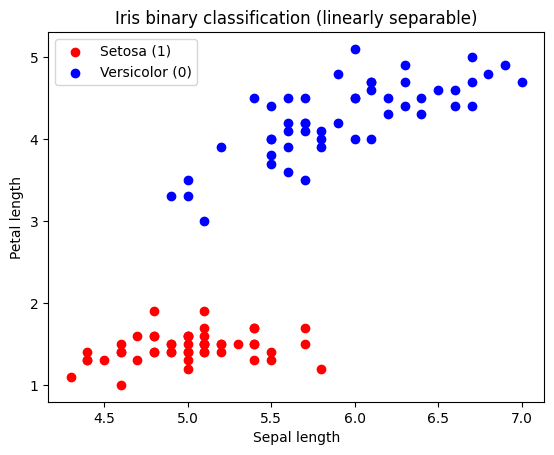

In [ ]:
plt.scatter(X[y==1, 0], X[y==1, 1], color='red', label='Setosa (1)')
plt.scatter(X[y==0, 0], X[y==0, 1], color='blue', label='Versicolor (0)')
plt.xlabel('Sepal length')
plt.ylabel('Petal length')
plt.legend()
plt.title('Iris binary classification (linearly separable)')
plt.show()

In [ ]:
class Perceptron:
    def __init__(self, learning_rate=0.1, n_iters=100):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Training loop
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                # Linear combination
                linear_output = np.dot(x_i, self.weights) + self.bias
                # Step activation function
                y_pred = 1 if linear_output >= 0 else 0

                # Perceptron update rule
                update = self.lr * (y[idx] - y_pred)
                self.weights += update * x_i
                self.bias += update

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, 0)

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (important for perceptron convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train perceptron
perceptron = Perceptron(learning_rate=0.1, n_iters=10)
perceptron.fit(X_train_scaled, y_train)

# Predictions
y_pred = perceptron.predict(X_test_scaled)

# Accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Test accuracy: {accuracy:.2f}")

# Show predictions vs actual
print("\nFirst 10 test samples:")
print(f"Predicted: {y_pred[:10]}")
print(f"Actual:    {y_test[:10]}")

Test accuracy: 0.95

First 10 test samples:
Predicted: [0 0 0 1 1 1 1 0 1 1]
Actual:    [0 0 0 1 1 1 1 0 1 1]


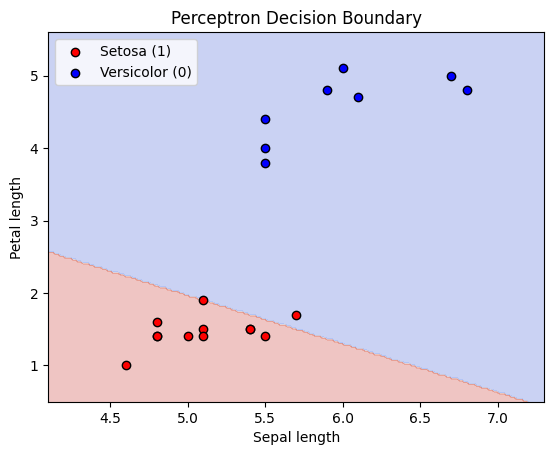

In [ ]:
# Plot decision boundary
def plot_decision_boundary(X, y, model, scaler):
    # Create mesh
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    # Scale mesh points
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    mesh_points_scaled = scaler.transform(mesh_points)

    # Predict
    Z = model.predict(mesh_points_scaled)
    Z = Z.reshape(xx.shape)

    # Plot
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[y==1, 0], X[y==1, 1], color='red', label='Setosa (1)', edgecolor='k')
    plt.scatter(X[y==0, 0], X[y==0, 1], color='blue', label='Versicolor (0)', edgecolor='k')
    plt.xlabel('Sepal length')
    plt.ylabel('Petal length')
    plt.legend()
    plt.title('Perceptron Decision Boundary')
    plt.show()

plot_decision_boundary(X_test, y_test, perceptron, scaler)

In [ ]:
# Take classes 1 (versicolor) and 2 (virginica) — not linearly separable
X_nonsep = iris.data[50:150, [0, 2]]  # all versicolor and virginica
y_nonsep = iris.target[50:150]
y_nonsep = np.where(y_nonsep == 1, 0, 1)  # Make versicolor=0, virginica=1

X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X_nonsep, y_nonsep, test_size=0.2, random_state=42
)

scaler_ns = StandardScaler()
X_train_ns_scaled = scaler_ns.fit_transform(X_train_ns)
X_test_ns_scaled = scaler_ns.transform(X_test_ns)

perceptron_ns = Perceptron(learning_rate=0.1, n_iters=100)
perceptron_ns.fit(X_train_ns_scaled, y_train_ns)

y_pred_ns = perceptron_ns.predict(X_test_ns_scaled)
accuracy_ns = np.mean(y_pred_ns == y_test_ns)
print(f"Non-separable test accuracy: {accuracy_ns:.2f}")

Non-separable test accuracy: 0.80
